# 01 — Data Consolidation

**Maps from previous project:** Notebook 01 (data cleaning / merge)

**Input:**
- `data/seed/companies_seed.csv`, `opportunities_seed.csv` (curated priority employers)
- DfE Find an Apprenticeship underlying vacancies (GL* postcodes) via `glos_recommender.vacancies`

**Tasks:**
1. Load seed employers + opportunities
2. Ingest Gloucestershire apprenticeship vacancies and merge (seed wins on name clash)
3. Clean / normalise pipe-separated tags
4. Exploratory analysis of sectors and entry routes

**Output:** `data/processed/companies_master.pkl`, `opportunities_master.pkl`

In [3]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from glos_recommender.vacancies import ensure_vacancies_available, merge_seed_with_vacancies

SEED_DIR = PROJECT_ROOT / "data" / "seed"
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
APP_DATA_DIR = PROJECT_ROOT / "app" / "app_data"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
APP_DATA_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load seed tables + merge apprenticeship vacancies

In [4]:
seed_companies = pd.read_csv(SEED_DIR / "companies_seed.csv")
seed_opportunities = pd.read_csv(SEED_DIR / "opportunities_seed.csv")

zip_path = ensure_vacancies_available(RAW_DIR / "apprenticeship_vacancies.zip")
companies, opportunities, vac_stats = merge_seed_with_vacancies(
    seed_companies,
    seed_opportunities,
    zip_path=zip_path,
)

print("Vacancy merge stats:")
for k, v in vac_stats.items():
    print(f"  {k}: {v}")
print(f"\nCompanies:     {companies.shape}")
print(f"Opportunities: {opportunities.shape}")
print("Sources:", companies["source"].value_counts().to_dict())
print("\nCompany columns:", list(companies.columns))
companies.head()

Vacancy merge stats:
  raw_vacancies: 261825
  gl_vacancies: 3599
  vacancy_employers_total: 1126
  vacancy_employers_added: 1119
  seed_companies: 20
  merged_companies: 1139
  merged_opportunities: 2192
  live_gl_vacancies: 69

Companies:     (1139, 17)
Opportunities: (2192, 11)
Sources: {'vacancies': 1119, 'seed': 20}

Company columns: ['company_id', 'name', 'town', 'postcode', 'sectors', 'entry_routes', 'role_families', 'size_band', 'priority_employer', 'hiring_signal', 'website', 'summary', 'profile_text', 'employer_key', 'source', 'n_vacancies_raw', 'n_live_vacancies']


,company_id,name,town,postcode,sectors,entry_routes,role_families,size_band,priority_employer,hiring_signal,website,summary,profile_text,employer_key,source,n_vacancies_raw,n_live_vacancies
0,GLC001,Renishaw,Wotton-under-Edge,GL12,aerospace_manufacturing|cyber_digital,apprenticeship|graduate|higher_apprenticeship,engineer_ops|software|manufacturing|technician,large,1,high,https://www.renishaw.com,Precision engineering and metrology employer w...,Renishaw Gloucestershire advanced manufacturin...,renishaw,seed,NaN,NaN
1,GLC002,Spirax Sarco,Cheltenham,GL53,aerospace_manufacturing|business_professional,apprenticeship|graduate,engineer_ops|manufacturing|project_coord|finance,large,1,high,https://www.spiraxsarco.com,Thermal energy and steam systems manufacturer ...,Spirax Sarco Cheltenham engineering manufactur...,spirax sarco,seed,NaN,NaN
2,GLC003,GE Aerospace,Gloucester area,GL2,aerospace_manufacturing,apprenticeship|graduate|higher_apprenticeship,engineer_ops|manufacturing|technician|quality,large,1,high,https://www.geaerospace.com,Major aerospace employer with engineering and ...,GE Aerospace Gloucestershire aerospace manufac...,ge aerospace,seed,NaN,NaN
3,GLC004,Moog,Tewkesbury,GL20,aerospace_manufacturing,apprenticeship|graduate,engineer_ops|manufacturing|technician|software,large,1,high,https://www.moog.com,Aerospace flight control systems manufacturer ...,Moog Tewkesbury aerospace flight controls manu...,moog,seed,NaN,NaN
4,GLC005,Safran Landing Systems,Gloucester area,GL2,aerospace_manufacturing,apprenticeship|graduate,engineer_ops|manufacturing|technician|quality,large,1,medium,https://www.safran-group.com,Aerospace landing systems manufacturer with te...,Safran Gloucestershire aerospace landing syste...,safran landing systems,seed,NaN,NaN


## 2. Clean & expand tags

In [5]:
def split_tags(series):
    return series.fillna("").apply(lambda x: [t.strip() for t in str(x).split("|") if t.strip()])

companies = companies.copy()
companies["sector_list"] = split_tags(companies["sectors"])
companies["entry_route_list"] = split_tags(companies["entry_routes"])
companies["role_family_list"] = split_tags(companies["role_families"])
companies["n_sectors"] = companies["sector_list"].str.len()
companies["n_entry_routes"] = companies["entry_route_list"].str.len()
companies["priority_employer"] = companies["priority_employer"].astype(int)

# Opportunity counts per company
opp_counts = opportunities.groupby("company_id").size().rename("n_opportunities")
companies = companies.merge(opp_counts, on="company_id", how="left")
companies["n_opportunities"] = companies["n_opportunities"].fillna(0).astype(int)

print(f"Nulls remaining: {companies.isna().sum().sum()}")
companies[["company_id", "name", "n_sectors", "n_entry_routes", "n_opportunities"]].head()

Nulls remaining: 40


,company_id,name,n_sectors,n_entry_routes,n_opportunities
0,GLC001,Renishaw,2,3,2
1,GLC002,Spirax Sarco,2,2,1
2,GLC003,GE Aerospace,1,3,1
3,GLC004,Moog,1,2,1
4,GLC005,Safran Landing Systems,1,2,0


## 3. Exploratory analysis

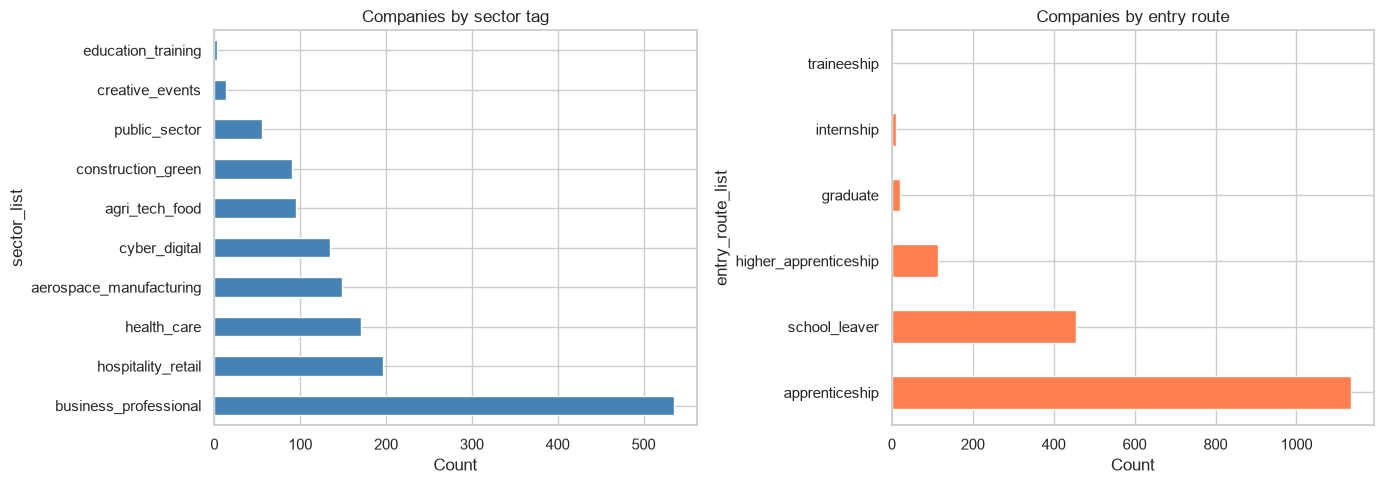

Hiring signal distribution:
hiring_signal
low       848
medium    240
high       51
Name: count, dtype: int64


In [6]:
sector_counts = companies.explode("sector_list")["sector_list"].value_counts()
route_counts = companies.explode("entry_route_list")["entry_route_list"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sector_counts.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Companies by sector tag")
axes[0].set_xlabel("Count")

route_counts.plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_title("Companies by entry route")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()

print("Hiring signal distribution:")
print(companies["hiring_signal"].value_counts())

In [7]:
print("Opportunities by entry route:")
print(opportunities["entry_route"].value_counts())

merged_preview = opportunities.merge(
    companies[["company_id", "name", "town"]], on="company_id", how="left"
)
merged_preview[["opportunity_id", "name", "title", "entry_route", "level"]].head(10)

Opportunities by entry route:
entry_route
apprenticeship    2185
graduate             4
internship           2
school_leaver        1
Name: count, dtype: int64


,opportunity_id,name,title,entry_route,level
0,OPP001,Renishaw,Engineering Apprenticeship,apprenticeship,Level 3-6
1,OPP002,Renishaw,Graduate Software / Engineering,graduate,Level 6+
2,OPP003,GE Aerospace,Aerospace Manufacturing Apprentice,apprenticeship,Level 3-4
3,OPP004,Moog,Flight Controls Engineering Pathway,apprenticeship,Level 3-6
4,OPP005,CyNam Network,Cyber Security Apprenticeship (cluster SMEs),apprenticeship,Level 3-4
5,OPP006,Ripjar,Graduate Analyst / Engineer,graduate,Level 6+
6,OPP007,Farm491,Agri-tech Internship,internship,any
7,OPP008,Hartpury University and College,Land-based / Equine / Sport Pathways,apprenticeship,Level 2-6
8,OPP009,NHS Gloucestershire,Healthcare Support Worker / Nursing Associate ...,apprenticeship,Level 2-5
9,OPP010,Gloucestershire County Council,Local Government Apprenticeship / Graduate,apprenticeship,Level 3-6


## 4. Save master tables

In [8]:
companies.to_pickle(PROCESSED_DIR / "companies_master.pkl")
opportunities.to_pickle(PROCESSED_DIR / "opportunities_master.pkl")

companies.to_csv(APP_DATA_DIR / "companies_master.csv", index=False)
opportunities.to_csv(APP_DATA_DIR / "opportunities_master.csv", index=False)

print(f"Saved companies_master: {companies.shape}")
print(f"Saved opportunities_master: {opportunities.shape}")
print("\nProceed to Notebook 02 — Feature Engineering.")

Saved companies_master: (1139, 23)
Saved opportunities_master: (2192, 11)

Proceed to Notebook 02 — Feature Engineering.
